# 07 - REAL DATA case study: BSEE OGOR-A
Separate from PetroNexa. Column names follow the author's understanding of the OGOR-A layout (files have no header); verify against the BSEE data dictionary. OGOR-B/C not used.

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT / "src"))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
pd.set_option("display.width", 160); pd.set_option("display.max_columns", 30); pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
from og_oip import config
NOTICE = config.SYNTHETIC_NOTICE
print(NOTICE)

All operational, production, financial, maintenance, inventory, sensor and HSE data in this project are synthetic/simulated and created for portfolio demonstration purposes. They do not represent actual operations of a real company.


In [2]:
from og_oip.real_data import bsee
d = bsee.load(); a = bsee.analyse(d); a["data_quality"]

                                                        check  value
0                                                        rows  85205
1                                             distinct months     18
2                                            unparsable month      0
3                            non-numeric oil/gas/water values      0
4                               negative oil/gas/water values      0
5                                     days_on_production > 31      0
6  rows repeated on (lease, completion, month, API, interval)      0
7                             rows with all three volumes = 0  54656
8           rows with volumes > 0 but days_on_production == 0      0
9        rows with days_on_production > 0 but all volumes = 0   1207

In [3]:
a["monthly"][["month","oil_bbl","gas_mcf","water_bbl","completions","operators","water_to_oil_ratio"]]

        month   oil_bbl   gas_mcf  water_bbl  completions  operators  water_to_oil_ratio
0  2025-01-01  56034961  58090056   32822461         5075         47                0.59
1  2025-02-01  49673730  52394411   30629985         4963         47                0.62
2  2025-03-01  56155887  60550399   34408007         4927         47                0.61
3  2025-04-01  54903761  58559171   31204625         4907         46                0.57
4  2025-05-01  57137177  61281528   32561877         4821         46                0.57
5  2025-06-01  58469587  62339306   34784264         4834         46                0.59
6  2025-07-01  59986591  65722676   33682184         4799         46                0.56
7  2025-08-01  62996525  67957109   35333713         4760         44                0.56
8  2025-09-01  61931894  65699914   35378355         4746         44                0.57
9  2025-10-01  66501289  70337281   36845224         4737         43                0.55
10 2025-11-01  620955

In [4]:
a["operators"].head(10)[["operator_name","oil_bbl","oil_share_pct","water_to_oil_ratio"]], a["concentration"]

(                                    operator_name    oil_bbl  oil_share_pct  water_to_oil_ratio
5                             SHELL OFFSHORE INC.  285342168          26.50                0.33
16                BP EXPLORATION & PRODUCTION INC  212773207          19.76                0.49
2                                 CHEVRON USA INC  124948634          11.61                0.28
7                  ANADARKO PETROLEUM CORPORATION  101074973           9.39                0.37
20  MURPHY EXPLORATION & PRODUCTION COMPANY - USA   52696765           4.89                0.30
12                  LLOG EXPLORATION OFFSHORE LLC   43249085           4.02                0.34
0                 UNION OIL COMPANY OF CALIFORNIA   30839477           2.86                0.06
42               BOE EXPLORATION & PRODUCTION LLC   28160532           2.62                0.03
1                                HESS CORPORATION   27217951           2.53                0.48
46                       TALOS QN EXPLO

In [5]:
a["areas"].head(8)

   area_prefix    oil_bbl    gas_mcf  water_bbl  completion_months  oil_share_pct
18          MC  431674465  439641416  196256784               9311          40.09
13          GC  320270896  258381116  109513079               6435          29.75
29          WR  122836929   47021170   17104103               1185          11.41
0           AC   68932860  107918871   10752191               1123           6.40
17          KC   33857584   21433947   16562037                471           3.14
12          GB   18575123   51701184   24701945               1141           1.73
10          EW   17608016   21445765   13362477               1913           1.64
5           DC   10864800    5253893    1485099                144           1.01

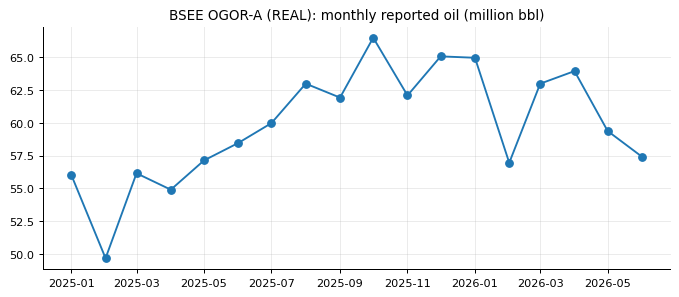

In [6]:
m = a["monthly"]; fig, ax = plt.subplots(figsize=(9,3.5)); ax.plot(m.month, m.oil_bbl/1e6, marker="o"); ax.set_title("BSEE OGOR-A (REAL): monthly reported oil (million bbl)"); plt.show()

18 months are too few for decline or seasonality conclusions. A falling completion count may reflect reporting changes as well as operations.